# Amazon Reviews - Exploratory Data Analysis

## CodeAlpha Data Analytics Internship

### Project Objective
This project focus on exploring and analyzing Amazon customer reviews to identify pattern, trends, and insights from customer ratings and review data.

### Objectives
- Understand the structure and quality of the Amazon reviews dataset.
- Analyze the distribution of customer ratings.
- Examine review activity over time.
- Identify products and users with the highest number of reviews.
- Investigate review length across different ratings.
- Analyze the relationship between customer ratings and review helpfulness.
- Present key findings through appropriate visualizations.

### Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

In [34]:
 import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
df = pd.read_csv ("../data/Amazon Review.csv")

# Exploratory Data Analysis

The dataset was examined to understand its size, structure, data types, missing values, duplicate records, and the distribution of important variables.

In [36]:
df.head ()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [37]:
df.shape

(568454, 10)

In [38]:
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [40]:
df.isnull().sum()

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

In [41]:
df.duplicated().sum()

np.int64(0)

In [42]:
df['Score'].value_counts().sort_index()

Score
1     52268
2     29769
3     42640
4     80655
5    363122
Name: count, dtype: int64

In [43]:
score_percentage=df['Score'].value_counts(normalize=True).sort_index()*100
score_percentage

Score
1     9.194763
2     5.236835
3     7.501047
4    14.188483
5    63.878871
Name: proportion, dtype: float64

In [44]:
df.describe()

,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,568454.000000,568454.000000,568454.00000,568454.000000,5.684540e+05
mean,284227.500000,1.743817,2.22881,4.183199,1.296257e+09
std,164098.679298,7.636513,8.28974,1.310436,4.804331e+07
min,1.000000,0.000000,0.00000,1.000000,9.393408e+08
25%,142114.250000,0.000000,0.00000,4.000000,1.271290e+09
50%,284227.500000,0.000000,1.00000,5.000000,1.311120e+09
75%,426340.750000,2.000000,2.00000,5.000000,1.332720e+09
max,568454.000000,866.000000,923.00000,5.000000,1.351210e+09


## Customer Rating Analysis

Customer ratings were analyzed to understand the distribution of ratings within the dataset and determine the overall level of customer satisfaction represented by the reviews.

In [45]:
df['Score'].describe()

count    568454.000000
mean          4.183199
std           1.310436
min           1.000000
25%           4.000000
50%           5.000000
75%           5.000000
max           5.000000
Name: Score, dtype: float64

In [46]:
average_score=df['Score'].mean()
print(f"Average customer rating: {average_score:2f} stars")

Average customer rating: 4.183199 stars


## Product and User Review Activity

The analysis identifies products and users with the highest number of reviews. This helps highlight products receiving significant customer attention and highly active reviewers within the dataset.

In [47]:
positive_reviews = df['Score'].isin([4,5])
positive_percentage=positive_reviews.mean()*100
print(f"Positive reviews: {positive_percentage:2f}%")

Positive reviews: 78.067355%


In [49]:
negative_reviews = df['Score'].isin([1,2])
negative_percentage=negative_reviews.mean()*100
print(f"Negative reviews:{negative_percentage:.2f}%")

Negative reviews:14.43%


In [50]:
neutral_reviews = df['Score']==3
neutral_percentage = neutral_reviews.mean()*100
print(f"Neutral reviews: {neutral_percentage:.2f}%")

Neutral reviews: 7.50%


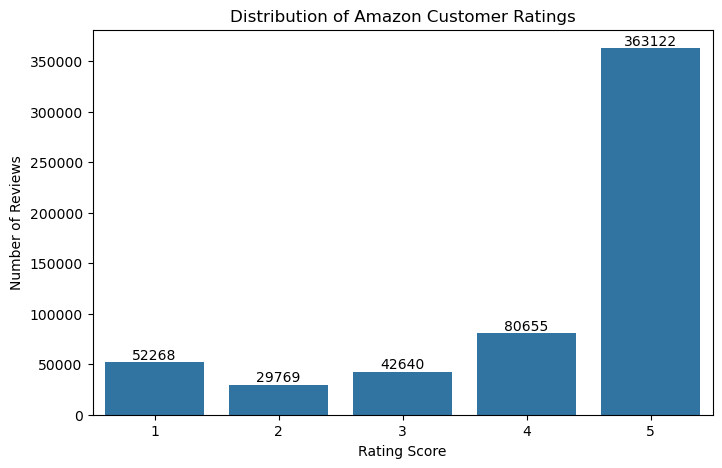

In [51]:
plt.figure(figsize=(8,5))

ax = sns.countplot(data=df, x='Score')

plt.title ('Distribution of Amazon Customer Ratings')
plt.xlabel('Rating Score')
plt.ylabel('Number of Reviews')

for container in ax.containers:
    ax.bar_label(container, fmt='%d')
    
plt.show()

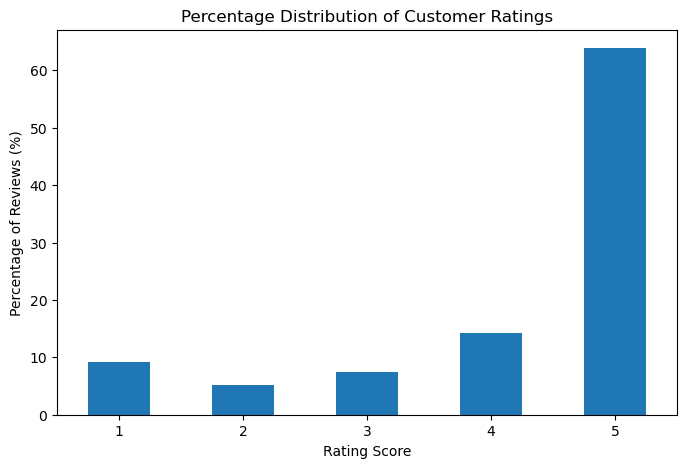

In [53]:
plt.figure(figsize=(8,5))

score_percentage.plot(kind='bar')

plt.title('Percentage Distribution of Customer Ratings')
plt.xlabel('Rating Score')
plt.ylabel('Percentage of Reviews (%)')

plt.xticks(rotation=0)
plt.show()

In [54]:
df['Text_Length'] = df['Text'].str.len()
df['Text_Length'].describe()

count    568454.000000
mean        436.222083
std         445.339741
min          12.000000
25%         179.000000
50%         302.000000
75%         527.000000
max       21409.000000
Name: Text_Length, dtype: float64

In [55]:
print(f"Average review length: {df['Text_Length'].mean():2f}characters")

Average review length: 436.222083characters


In [56]:
print(f"Longest review: {df['Text_Length'].max():,} characters")

Longest review: 21,409 characters


In [57]:
df['Helpfulness_Ratio']= np.where(
    df['HelpfulnessDenominator']>0,
    df['HelpfulnessNumerator'] / df['HelpfulnessDenominator'],
    np.nan
)

In [58]:
df['Helpfulness_Ratio'].describe()

count    298402.000000
mean          0.776975
std           0.346321
min           0.000000
25%           0.600000
50%           1.000000
75%           1.000000
max           3.000000
Name: Helpfulness_Ratio, dtype: float64

In [59]:
helpfulness_by_score = (
    df.groupby('Score')['Helpfulness_Ratio']
    .mean()
    .round(3)
)
helpfulness_by_score

Score
1    0.539
2    0.566
3    0.626
4    0.791
5    0.872
Name: Helpfulness_Ratio, dtype: float64

## Review Trends Over Time

The review timestamp was converted into a readable date format to examine changes in review activity across different years.

In [60]:
df['Review_Date'] = pd.to_datetime(df['Time'], unit='s')

In [61]:
df['Review_Year'] = df['Review_Date'].dt.year
df['Review_Month'] = df['Review_Date'].dt.month
df['Review_Day'] = df['Review_Date'].dt.day

In [62]:
print("Earliest review:", df['Review_Date'].min())
print("Latest review:", df['Review_Date'].max())

Earliest review: 1999-10-08 00:00:00
Latest review: 2012-10-26 00:00:00


In [63]:
df[['Time', 'Review_Date', 'Review_Year']].head()

,Time,Review_Date,Review_Year
0,1303862400,2011-04-27,2011
1,1346976000,2012-09-07,2012
2,1219017600,2008-08-18,2008
3,1307923200,2011-06-13,2011
4,1350777600,2012-10-21,2012


In [64]:
reviews_by_year = df['Review_Year'].value_counts().sort_index()
reviews_by_year

Review_Year
1999         6
2000        32
2001        13
2002        73
2003       132
2004       561
2005      1335
2006      6671
2007     22300
2008     34163
2009     55326
2010     85884
2011    163299
2012    198659
Name: count, dtype: int64

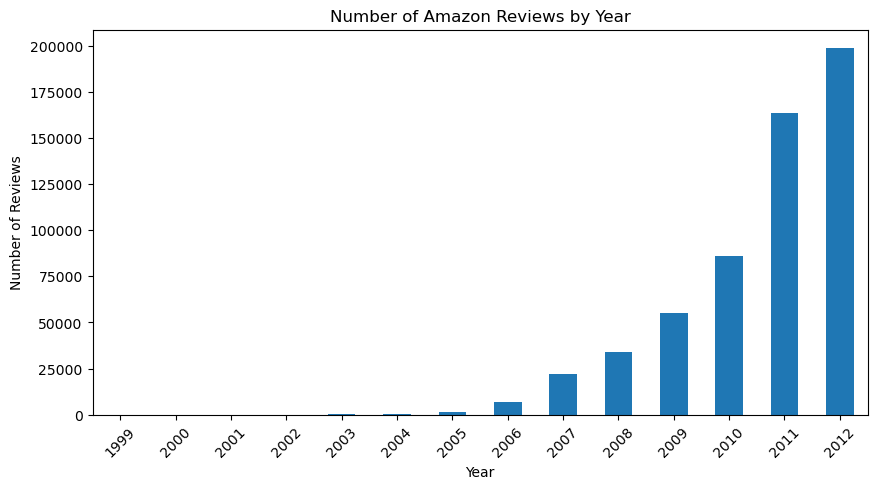

In [65]:
plt.figure(figsize=(10,5))

reviews_by_year.plot(kind='bar')

plt.title('Number of Amazon Reviews by Year')
plt.xlabel('Year')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)

plt.show()

In [66]:
top_products = (
    df['ProductId']
    .value_counts()
    .head(10)
)
top_products

ProductId
B007JFMH8M    913
B0026RQTGE    632
B002QWHJOU    632
B002QWP89S    632
B002QWP8H0    632
B003B3OOPA    623
B001EO5Q64    567
B000VK8AVK    564
B0026KNQSA    564
B007M83302    564
Name: count, dtype: int64

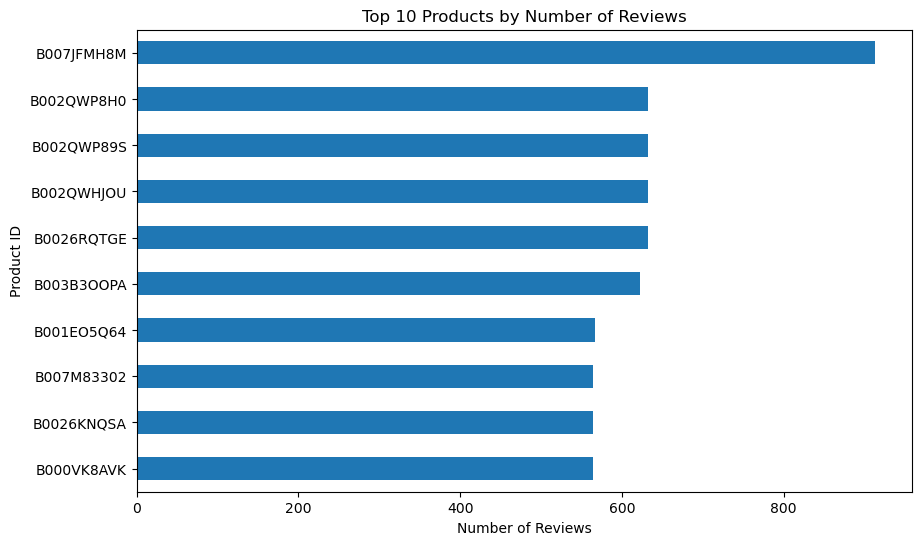

In [67]:
plt.figure(figsize=(10,6))

top_products.sort_values().plot(kind='barh')

plt.title('Top 10 Products by Number of Reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('Product ID')

plt.show()

In [68]:
top_users = (
    df['UserId']
    .value_counts()
    .head(10)
)
top_users

UserId
A3OXHLG6DIBRW8    448
A1YUL9PCJR3JTY    421
AY12DBB0U420B     389
A281NPSIMI1C2R    365
A1Z54EM24Y40LL    256
A1TMAVN4CEM8U8    204
A2MUGFV2TDQ47K    201
A3TVZM3ZIXG8YW    199
A3PJZ8TU8FDQ1K    178
AQQLWCMRNDFGI     176
Name: count, dtype: int64

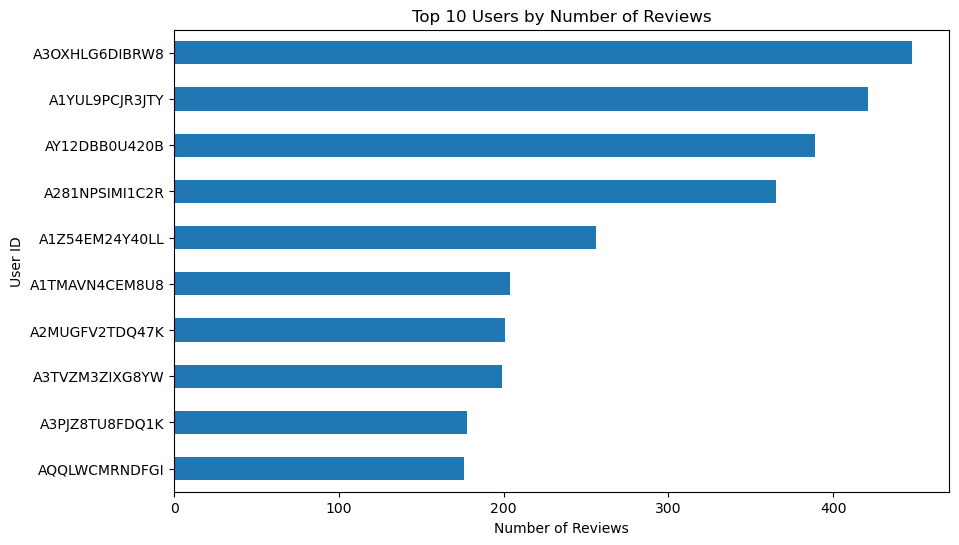

In [69]:
plt.figure(figsize=(10,6))

top_users.sort_values().plot(kind='barh')

plt.title('Top 10 Users by Number of Reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('User ID')

plt.show()

In [70]:
df['Text_Length']

0         263
1         190
2         509
3         219
4         140
         ... 
568449    149
568450    252
568451    372
568452    200
568453    111
Name: Text_Length, Length: 568454, dtype: int64

In [71]:
review_length_by_score = (
    df.groupby('Score')['Text_Length']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .round(2)
)
review_length_by_score

,count,mean,median,min,max
Score,,,,,
1,52268,478.08,338.0,12,11861
2,29769,490.66,357.0,33,9295
3,42640,520.32,374.0,32,21409
4,80655,496.60,347.0,35,12518
5,363122,402.45,277.0,18,16952


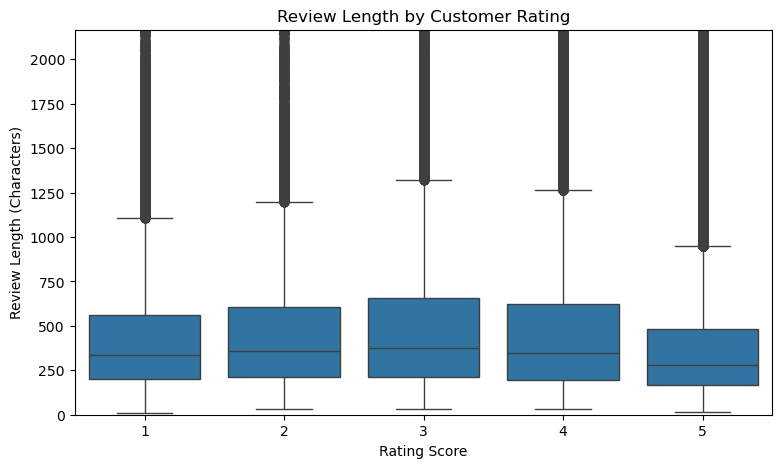

In [73]:
plt.figure(figsize=(9,5))

sns.boxplot(data=df, x='Score', y='Text_Length')

plt.title('Review Length by Customer Rating')
plt.xlabel('Rating Score')
plt.ylabel('Review Length (Characters)')

plt.ylim(0, df['Text_Length'].quantile(0.99))

plt.show()

## Review Helpfulness Analysis

Helpfulness was examined to understand how useful customers considered different reviews. The relationship between helpfulness and customer rating was also explored.

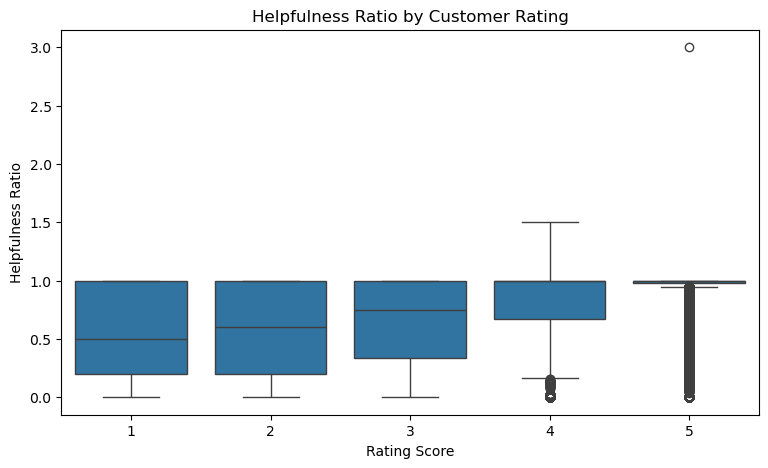

In [74]:
plt.figure(figsize=(9,5))

sns.boxplot(
    data=df,
    x='Score',
    y='Helpfulness_Ratio'
)
plt.title('Helpfulness Ratio by Customer Rating')
plt.xlabel('Rating Score')
plt.ylabel('Helpfulness Ratio')

plt.show()

# Conclusion

The analysis of the Amazon reviews dataset revealed several important patterns in customer feedback.

The dataset contains 568,454 reviews and has no duplicate records. The overall average customer rating is approximately 4.18 out of 5, indicating that the reviews are generally positive. Five-star reviews make up the largest proportion of the dataset.

Review activity increased substantially over the years, with the highest volumes occurring in the later years of the dataset. The analysis also identified products and users with particularly high numbers of reviews.

Review length and helpfulness were further examined across customer ratings to understand differences in customer feedback behaviour.

Overall, the analysis demonstrates how exploratory data analysis and visualization can be used to identify patterns in large-scale customer review data and generate useful insights about customer behaviour and product engagement. 